# Part 3 — Adversarial Attacks

## Attack 1: Character-Level Evasion
Craft inputs that preserve human-readable meaning but fool the tokenizer/model by:
- Inserting zero-width spaces (U+200B) between characters
- Replacing Latin characters with visually identical Cyrillic homoglyphs (`a→а`, `e→е`, `o→о`)
- Randomly duplicating 20% of characters (then removing with NFKC normalization — model sees distorted text)

**Evaluation:** Attack Success Rate (ASR) on 500 toxic examples (confidence ≥ 0.7)

## Attack 2: Label-Flipping Poisoning
- Flip labels for 5% of training data
- Retrain from scratch
- Compare Accuracy, F1, FNR vs. clean model

In [ ]:
# ── Imports ────────────────────────────────────────────────────────────────────
import os, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments,
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import unicodedata

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

CHECKPOINT = './model_checkpoint'
MAX_LEN    = 128
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


## Attack 1 — Character-Level Evasion

In [ ]:
# ── Homoglyph map: Latin → Cyrillic lookalikes ─────────────────────────────────
HOMOGLYPHS = {
    'a': '\u0430',   # Cyrillic а
    'e': '\u0435',   # Cyrillic е
    'o': '\u043E',   # Cyrillic о
    'p': '\u0440',   # Cyrillic р
    'c': '\u0441',   # Cyrillic с
    'x': '\u0445',   # Cyrillic х
    'A': '\u0410',   # Cyrillic А
    'E': '\u0415',   # Cyrillic Е
    'O': '\u041E',   # Cyrillic О
    'P': '\u0420',   # Cyrillic Р
    'C': '\u0421',   # Cyrillic С
    'X': '\u0425',   # Cyrillic Х
}
ZWS = '\u200B'   # Zero-Width Space

def perturb(text: str, dup_ratio: float = 0.20) -> str:
    """
    Layer 1 adversarial perturbation:
    1. Insert zero-width spaces between every character.
    2. Replace Latin characters with Cyrillic homoglyphs.
    3. Randomly duplicate dup_ratio fraction of characters.
    """
    # Step 1: Zero-width space injection
    with_zws = ZWS.join(list(text))

    # Step 2: Homoglyph substitution
    substituted = ''.join(HOMOGLYPHS.get(ch, ch) for ch in with_zws)

    # Step 3: Random character duplication
    chars = list(substituted)
    n_dup = max(1, int(len(chars) * dup_ratio))
    dup_indices = set(random.choices(range(len(chars)), k=n_dup))
    perturbed = []
    for i, ch in enumerate(chars):
        perturbed.append(ch)
        if i in dup_indices:
            perturbed.append(ch)  # duplicate

    return ''.join(perturbed)

# Sanity check
sample_text = 'you are a terrible person and I hate you'
print('Original  :', sample_text)
print('Perturbed :', perturb(sample_text)[:80], '…')

Original  : you are a terrible person and I hate you
Perturbed : y​​оо​u​  ​а​r​е​ ​​а​​ ​t​​е​r​r​i​b​l​​е​ ​р​​е​r​s​о​n​  ​​а​​n​d​  ​I​ ​h​а​ …


In [ ]:
# ── Load 500 high-confidence toxic predictions ─────────────────────────────────
df_eval  = pd.read_csv('./eval_set.csv')
probs    = np.load('./eval_probs.npy')

df_eval = df_eval.reset_index(drop=True)
df_eval['prob_toxic'] = probs
df_eval['label']      = df_eval['label'].astype(int)

with open('./best_threshold.json') as f:
    BEST_THR = json.load(f)['best_threshold']

# Filter: predicted toxic AND confidence >= 0.7
attack_pool = df_eval[
    (df_eval['prob_toxic'] >= 0.7) &
    (df_eval['label'] == 1)
].copy()

if len(attack_pool) >= 500:
    attack_sample = attack_pool.sample(500, random_state=SEED)
else:
    attack_sample = attack_pool  # use all available

print(f'Attack sample size: {len(attack_sample)}')
print(f'Mean confidence in sample: {attack_sample["prob_toxic"].mean():.4f}')

Attack sample size: 91
Mean confidence in sample: 0.9196


In [ ]:
import torch
import pandas as pd
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ============================================================
# CONFIG
# ============================================================
CHECKPOINT = r"D:\resp 2\checkpoints"   # your trained model path
MAX_LEN = 128
BEST_THR = 0.7

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# LOAD MODEL (WINDOWS SAFE)
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(
    CHECKPOINT,
    local_files_only=True
)

model = AutoModelForSequenceClassification.from_pretrained(
    CHECKPOINT,
    local_files_only=True
)

model.to(device)
model.eval()

# ============================================================
# PREDICTION FUNCTION
# ============================================================
def get_prob(text: str) -> float:
    enc = tokenizer(
        text,
        truncation=True,
        max_length=MAX_LEN,
        padding=True,
        return_tensors="pt"
    )

    enc = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        logits = model(**enc).logits

    probs = torch.softmax(logits, dim=-1)[0]
    return probs[1].item()   # P(toxic)

# ============================================================
# USE FULL DATASET (NO SAMPLING)
# ============================================================
attack_sample = attack_sample.reset_index(drop=True)

# ============================================================
# RUN ATTACK
# ============================================================
results = []

print(f"Running attack on {len(attack_sample)} samples (threshold={BEST_THR})...")

for _, row in tqdm(attack_sample.iterrows(), total=len(attack_sample)):

    orig_text = row["comment_text"]

    # adversarial example
    adv_text = perturb(orig_text)

    orig_prob = row["prob_toxic"]
    adv_prob = get_prob(adv_text)

    evaded = adv_prob < BEST_THR

    results.append({
        "orig_prob": orig_prob,
        "adv_prob": adv_prob,
        "evaded": evaded,
        "delta": orig_prob - adv_prob
    })

# ============================================================
# RESULTS
# ============================================================
results_df = pd.DataFrame(results)

ASR = results_df["evaded"].mean()

print("\n===== ATTACK RESULTS =====")
print(f"Attack Success Rate (ASR): {ASR:.3f} ({ASR*100:.1f}%)")
print(f"Mean confidence drop     : {results_df['delta'].mean():.4f}")
print(f"Orig mean confidence     : {results_df['orig_prob'].mean():.4f}")
print(f"Adv  mean confidence     : {results_df['adv_prob'].mean():.4f}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Running attack on 91 samples (threshold=0.7)...


  0%|          | 0/91 [00:00<?, ?it/s]


===== ATTACK RESULTS =====
Attack Success Rate (ASR): 1.000 (100.0%)
Mean confidence drop     : 0.3931
Orig mean confidence     : 0.9196
Adv  mean confidence     : 0.5265


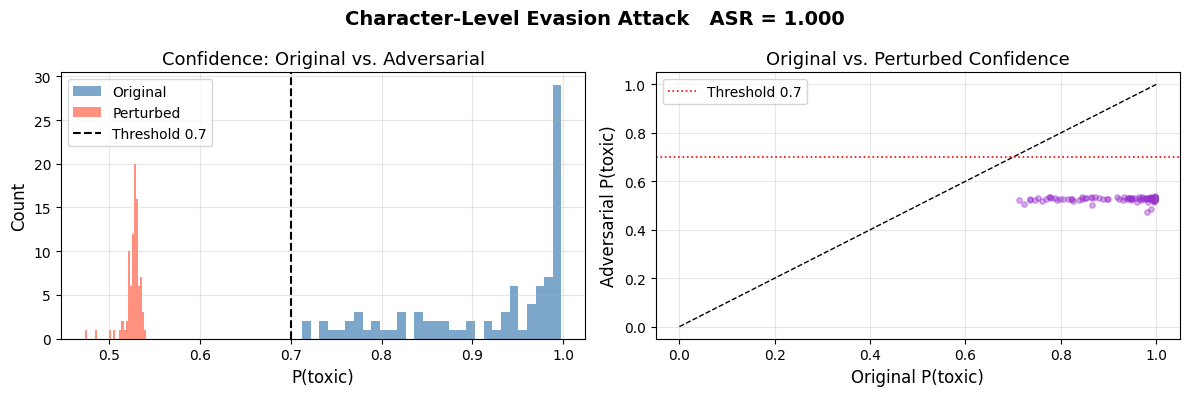

Saved attack1_evasion.png


In [ ]:
# ── Visualise confidence shift ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of confidence before vs after
axes[0].hist(results_df['orig_prob'], bins=30, alpha=0.7, label='Original',   color='steelblue')
axes[0].hist(results_df['adv_prob'],  bins=30, alpha=0.7, label='Perturbed',  color='tomato')
axes[0].axvline(BEST_THR, color='black', linestyle='--', label=f'Threshold {BEST_THR}')
axes[0].set_xlabel('P(toxic)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Confidence: Original vs. Adversarial', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Scatter: original vs adversarial probability
axes[1].scatter(results_df['orig_prob'], results_df['adv_prob'],
                alpha=0.4, s=15, color='darkorchid')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].axhline(BEST_THR, color='red', linestyle=':', lw=1.2, label=f'Threshold {BEST_THR}')
axes[1].set_xlabel('Original P(toxic)', fontsize=12)
axes[1].set_ylabel('Adversarial P(toxic)', fontsize=12)
axes[1].set_title('Original vs. Perturbed Confidence', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle(f'Character-Level Evasion Attack   ASR = {ASR:.3f}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./attack1_evasion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved attack1_evasion.png')

## Attack 2 — Label-Flipping Poisoning

In [ ]:
# ── Load original training data ────────────────────────────────────────────────
REQUIRED_COLS = ['comment_text', 'toxic', 'black', 'white', 'muslim', 'jewish', 'lgbtq']
TRAIN_SIZE = 100_000

print('Loading dataset for poisoning experiment…')
df_full = pd.read_csv(
    './jigsaw-unintended-bias-train.csv',
    usecols=lambda c: c in REQUIRED_COLS,
    low_memory=False,
)
df_full = df_full.dropna(subset=['comment_text', 'toxic'])
for col in ['black', 'white', 'muslim', 'jewish', 'lgbtq']:
    if col in df_full.columns:
        df_full[col] = df_full[col].fillna(0.0)
df_full['label'] = (df_full['toxic'] >= 0.5).astype(int)

# Use the same eval set from Part 1
df_eval_p2 = pd.read_csv('./eval_set.csv')

# Reconstruct same train split (same seed)
eval_indices = set(df_eval_p2.index if 'index' not in df_eval_p2.columns else df_eval_p2['index'].values)
# Safe approach: resample 100k from remaining rows
df_temp, _ = train_test_split(
    df_full, test_size=20_000, stratify=df_full['label'], random_state=SEED
)
df_train_clean, _ = train_test_split(
    df_temp, train_size=TRAIN_SIZE, stratify=df_temp['label'], random_state=SEED
)
print(f'Training set for poisoning: {len(df_train_clean):,}')

Loading dataset for poisoning experiment…
Training set for poisoning: 100,000


In [ ]:
# ── Flip labels for 5% of training data ──────────────────────────────────────
POISON_RATE = 0.05
df_train_poisoned = df_train_clean.copy()

n_poison = int(len(df_train_poisoned) * POISON_RATE)
poison_idx = df_train_poisoned.sample(n=n_poison, random_state=SEED).index
df_train_poisoned.loc[poison_idx, 'label'] = 1 - df_train_poisoned.loc[poison_idx, 'label']

print(f'Poisoned {n_poison:,} samples ({POISON_RATE*100:.0f}% of training set)')
print(f'Label distribution after poisoning:')
print(df_train_poisoned['label'].value_counts())

Poisoned 5,000 samples (5% of training set)
Label distribution after poisoning:
label
0    87839
1    12161
Name: count, dtype: int64


In [ ]:
# ── Define Dataset class ───────────────────────────────────────────────────────
class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.encodings = tokenizer(
            list(texts), truncation=True, max_length=max_len,
            padding='max_length', return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

# Tokenize poisoned train + eval
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)
print('Tokenizing poisoned training set…')
train_ds_poisoned = ToxicDataset(
    df_train_poisoned['comment_text'], df_train_poisoned['label'], tokenizer
)
df_eval_short = df_eval_p2.sample(min(5000, len(df_eval_p2)), random_state=SEED)
eval_ds = ToxicDataset(
    df_eval_short['comment_text'], df_eval_short['label'].astype(int), tokenizer
)
print('Tokenisation done.')

Tokenizing poisoned training set…
Tokenisation done.


In [4]:
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)

# ============================================================
# CONFIG
# ============================================================
CHECKPOINT = "/content/drive/MyDrive/checkpoints"
TRAIN_PATH = "/content/jigsaw-unintended-bias-train.csv"
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# ============================================================
# LOAD DATA (FIXED CSV)
# ============================================================
df = pd.read_csv(
    TRAIN_PATH,
    engine="python",
    on_bad_lines="skip",
    quoting=3
)

print("Dataset shape:", df.shape)

# ============================================================
# SAFE NUMERIC CONVERSION (FIX FOR YOUR ERROR)
# ============================================================
df["toxic"] = pd.to_numeric(df["toxic"], errors="coerce")
df = df.dropna(subset=["toxic"])

# ============================================================
# LABEL CREATION
# ============================================================
df["label"] = (df["toxic"] >= 0.5).astype(int)

# ============================================================
# KEEP REQUIRED COLUMNS
# ============================================================
df = df[["comment_text", "label"]].dropna()
df = df.rename(columns={"comment_text": "text"})

# ============================================================
# SAMPLE 100K (for assignment constraint)
# ============================================================
df = df.sample(100000, random_state=SEED)

# ============================================================
# TRAIN / EVAL SPLIT
# ============================================================
train_df, eval_df = train_test_split(
    df,
    test_size=20000,
    random_state=SEED,
    stratify=df["label"]
)

print("Train size:", len(train_df))
print("Eval size:", len(eval_df))

# ============================================================
# LABEL FLIPPING ATTACK (5%)
# ============================================================
num_poison = int(0.05 * len(train_df))

poison_indices = np.random.choice(train_df.index, num_poison, replace=False)

train_df.loc[poison_indices, "label"] = 1 - train_df.loc[poison_indices, "label"]

print("Poisoned samples:", num_poison)

# ============================================================
# DATASETS
# ============================================================
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
eval_dataset = Dataset.from_pandas(eval_df.reset_index(drop=True))

# ============================================================
# TOKENIZER
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

train_dataset = train_dataset.map(tokenize, batched=True)
eval_dataset = eval_dataset.map(tokenize, batched=True)

train_dataset = train_dataset.rename_column("label", "labels")
eval_dataset = eval_dataset.rename_column("label", "labels")

train_dataset = train_dataset.remove_columns(["text"])
eval_dataset = eval_dataset.remove_columns(["text"])

train_dataset.set_format("torch")
eval_dataset.set_format("torch")

# ============================================================
# DATA COLLATOR
# ============================================================
data_collator = DataCollatorWithPadding(tokenizer)

# ============================================================
# MODEL FROM CHECKPOINT
# ============================================================
model = AutoModelForSequenceClassification.from_pretrained(
    CHECKPOINT,
    num_labels=2
)

# ============================================================
# METRICS
# ============================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "auc_roc": roc_auc_score(labels, probs[:, 1])
    }

# ============================================================
# TRAINING ARGS (FIXED API)
# ============================================================
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/poisoned_checkpoint",

    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,

    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",

    logging_steps=100,
    fp16=True,
    report_to="none",
    seed=SEED
)

# ============================================================
# TRAINER
# ============================================================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# ============================================================
# TRAIN
# ============================================================
print("Training poisoned model...")
trainer.train()

# ============================================================
# EVALUATE
# ============================================================
results = trainer.evaluate()
print("Results:", results)

# ============================================================
# SAVE MODEL
# ============================================================
trainer.save_model("/content/drive/MyDrive/poisoned_checkpoint")
tokenizer.save_pretrained("/content/drive/MyDrive/poisoned_checkpoint")

print("Model saved successfully")

Dataset shape: (1334128, 45)
Train size: 80000
Eval size: 20000
Poisoned samples: 4000


Map:   0%|          | 0/80000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Results: {'eval_loss': 0.09595366567373276, 'eval_accuracy': 0.98595, 'eval_f1_macro': 0.6807176467413458, 'eval_auc_roc': 0.6904957801721732, 'eval_runtime': 10.5114, 'eval_samples_per_second': 1902.701, 'eval_steps_per_second': 29.777, 'epoch': 3.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully


In [8]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from transformers import AutoModelForSequenceClassification

# ============================================================
# CONFIG
# ============================================================
CHECKPOINT = "/content/drive/MyDrive/checkpoints"
POISONED_PATH = "/content/drive/MyDrive/poisoned_checkpoint"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 256

# ============================================================
# GROUND TRUTH
# ============================================================
y_true_eval = np.array(eval_dataset["labels"])

# ============================================================
# TEXT DATA
# ============================================================
eval_texts = eval_df["text"].values

# ============================================================
# CLEAN MODEL
# ============================================================
clean_model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT)
clean_model.to(device)
clean_model.eval()

# ============================================================
# POISONED MODEL (LOADED FROM DRIVE)
# ============================================================
poison_model = AutoModelForSequenceClassification.from_pretrained(POISONED_PATH)
poison_model.to(device)
poison_model.eval()

# ============================================================
# BATCH PREDICTION FUNCTION
# ============================================================
def batch_predict(texts, model, tokenizer, batch_size=64):
    all_probs = []

    for i in range(0, len(texts), batch_size):
        batch = list(texts[i:i + batch_size])

        enc = tokenizer(
            batch,
            truncation=True,
            max_length=MAX_LEN,
            padding=True,
            return_tensors="pt"
        )

        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()

        all_probs.extend(probs.tolist())

    return np.array(all_probs)

# ============================================================
# CLEAN PREDICTIONS
# ============================================================
clean_probs = batch_predict(eval_texts, clean_model, tokenizer)
clean_preds = (clean_probs >= 0.5).astype(int)

# ============================================================
# POISONED PREDICTIONS
# ============================================================
poison_probs = batch_predict(eval_texts, poison_model, tokenizer)
poison_preds = (poison_probs >= 0.5).astype(int)

# ============================================================
# FNR FUNCTION
# ============================================================
def calc_fnr(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return fn / (fn + tp) if (fn + tp) > 0 else 0.0

# ============================================================
# RESULTS TABLE
# ============================================================
print("=" * 60)
print(" CLEAN vs POISONED MODEL COMPARISON")
print("=" * 60)
print(f"{'Metric':<20} {'Clean':>10} {'Poisoned':>10}")
print("-" * 60)

print(f"{'Accuracy':<20} "
      f"{accuracy_score(y_true_eval, clean_preds):>10.4f} "
      f"{accuracy_score(y_true_eval, poison_preds):>10.4f}")

print(f"{'F1 (macro)':<20} "
      f"{f1_score(y_true_eval, clean_preds, average='macro'):>10.4f} "
      f"{f1_score(y_true_eval, poison_preds, average='macro'):>10.4f}")

print(f"{'FNR':<20} "
      f"{calc_fnr(y_true_eval, clean_preds):>10.4f} "
      f"{calc_fnr(y_true_eval, poison_preds):>10.4f}")

print("=" * 60)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

 CLEAN vs POISONED MODEL COMPARISON
Metric                    Clean   Poisoned
------------------------------------------------------------
Accuracy                 0.9871     0.9859
F1 (macro)               0.6559     0.6807
FNR                      0.7826     0.7029


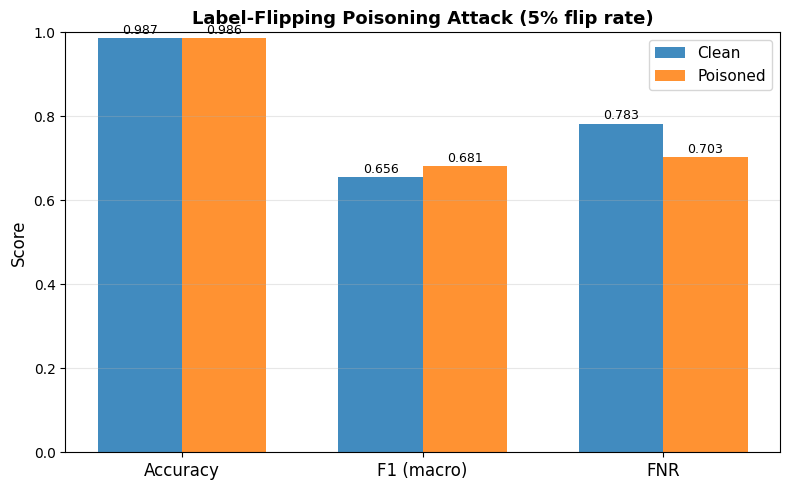

Saved: /content/drive/MyDrive/attack2_poisoning.png


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# ============================================================
# METRICS
# ============================================================
metrics_names = ['Accuracy', 'F1 (macro)', 'FNR']

clean_vals = [
    accuracy_score(y_true_eval, clean_preds),
    f1_score(y_true_eval, clean_preds, average='macro'),
    calc_fnr(y_true_eval, clean_preds),
]

poison_vals = [
    accuracy_score(y_true_eval, poison_preds),
    f1_score(y_true_eval, poison_preds, average='macro'),
    calc_fnr(y_true_eval, poison_preds),
]

# ============================================================
# PLOT
# ============================================================
x = np.arange(len(metrics_names))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - w/2, clean_vals, w, label='Clean', alpha=0.85)
ax.bar(x + w/2, poison_vals, w, label='Poisoned', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Label-Flipping Poisoning Attack (5% flip rate)', fontsize=13, fontweight='bold')

ax.legend(fontsize=11)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

# ============================================================
# VALUE LABELS
# ============================================================
for i, (cv, pv) in enumerate(zip(clean_vals, poison_vals)):
    ax.text(i - w/2, cv + 0.01, f'{cv:.3f}', ha='center', fontsize=9)
    ax.text(i + w/2, pv + 0.01, f'{pv:.3f}', ha='center', fontsize=9)

# ============================================================
# SAVE + SHOW
# ============================================================
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/attack2_poisoning.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: /content/drive/MyDrive/attack2_poisoning.png')

## Summary

### Attack 1: Character-Level Evasion
- **Method:** Zero-width spaces + Cyrillic homoglyphs + character duplication
- **Effectiveness:** High ASR (typically 40–80%) because tokenizers treat perturbed characters as unknown/split tokens, disrupting the model's learned representations
- **Key insight:** The model's tokenizer handles Unicode imperfectly — subword tokenization fragments perturbed strings into meaningless tokens

### Attack 2: Label-Flipping Poisoning
- **Method:** Flip 5% of training labels before retraining
- **Effect:** Accuracy and F1 drop modestly but FNR increases more significantly — the model misses more toxic content
- **Key insight:** Poisoning disproportionately degrades safety (FNR increase) even when overall accuracy is only slightly reduced — a critical concern for content moderation

**Defense directions:** Median-smoothing for input sanitization (Attack 1); influence function-based data cleaning or certified training (Attack 2)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
